<a href="https://colab.research.google.com/github/Swostika-Lama/PhishDetectAI/blob/main/notebooks/exploration_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing the Dataset - 2

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import pandas as pd

df_enron = pd.read_csv('/content/drive/MyDrive/PhishDetectAI/datasets/raw_data/Enron.csv')
df_enron.head()


,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0


In [3]:
df_enron

,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0
...,...,...,...
29762,confidence is back,"hello ,\r\nmy boyfriend began having problems ...",1
29763,important information,love - potion for your darling is all you want...,1
29764,vys - make itnger,you have feelings of guilt and embarrassment ...,1
29765,the best thing come in large parcels,spur - m formula\r\nincrease sperm production ...,1


##Basic Inspection

In [4]:
df_enron.shape

(29767, 3)

In [5]:
df_enron.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29767 entries, 0 to 29766
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   subject  29569 non-null  object
 1   body     29767 non-null  object
 2   label    29767 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 697.8+ KB


In [6]:
df_enron.head()

,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0


In [7]:
df_enron.columns

Index(['subject', 'body', 'label'], dtype='object')

##Missing values


In [8]:
df_enron.isnull().sum()

,0
subject,198
body,0
label,0


In [9]:
df_enron[df_enron['subject'].isnull()].head()


,subject,body,label
3517,NaN,the only fix to penis growth\r\nlimited time o...,1
3524,NaN,a permanent solution to penis growth\r\nlimite...,1
3540,NaN,a only fix to penis enlargement\r\nlimited tim...,1
3543,NaN,the only solution to penis growth\r\nlimited t...,1
3566,NaN,html\r\nbody\r\npbr\r\n/ p\r\np align = center...,1


##Duplicates


In [10]:
df_enron.duplicated().sum()

np.int64(0)

##Text length

In [11]:
df_enron['body'] = df_enron['body'].fillna('')
df_enron['text_length'] = df_enron['body'].apply(len)
df_enron['text_length'].describe()

,text_length
count,29767.000000
mean,1487.822421
std,4202.647954
min,1.000000
25%,332.000000
50%,706.000000
75%,1565.000000
max,230120.000000


##UNIVARIATE EDA

In [12]:
df_enron.describe()

,label,text_length
count,29767.000000,29767.000000
mean,0.469513,1487.822421
std,0.499078,4202.647954
min,0.000000,1.000000
25%,0.000000,332.000000
50%,0.000000,706.000000
75%,1.000000,1565.000000
max,1.000000,230120.000000


##Histogram of text length

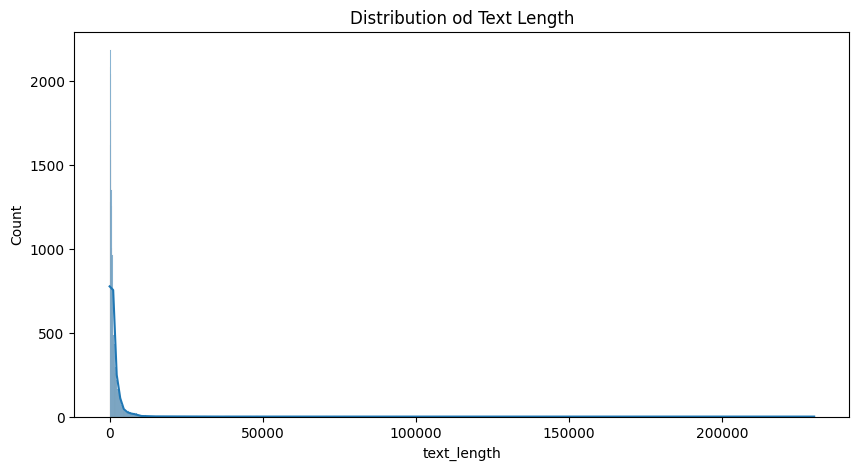

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df_enron['text_length'], kde=True)
plt.title("Distribution od Text Length")
plt.show()

##Label distribution

In [14]:
df_enron['label'].value_counts()




,count
label,
0,15791
1,13976


In [15]:
df_enron['label'].value_counts(normalize=True) * 100

,proportion
label,
0,53.048678
1,46.951322


##Subject length

In [16]:
df_enron['subject_length'] = df_enron['subject'].astype(str).apply(len)
df_enron['subject_length'].describe()


,subject_length
count,29767.000000
mean,34.093325
std,47.739892
min,1.000000
25%,19.000000
50%,30.000000
75%,44.000000
max,7170.000000


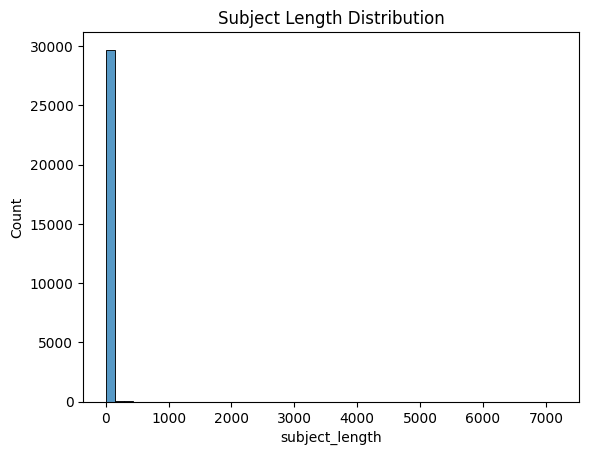

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_enron['subject_length'], bins=50)
plt.title("Subject Length Distribution")
plt.show()


##Body_length

In [18]:
df_enron['body_length'] = df_enron['body'].astype(str).apply(len)
df_enron['body_length'].describe()


,body_length
count,29767.000000
mean,1487.822421
std,4202.647954
min,1.000000
25%,332.000000
50%,706.000000
75%,1565.000000
max,230120.000000


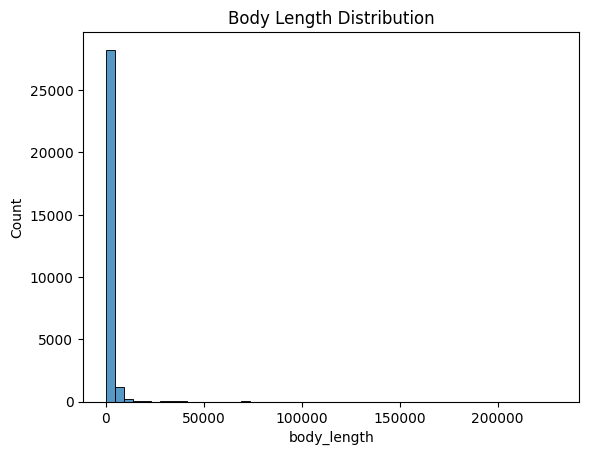

In [19]:
sns.histplot(df_enron['body_length'], bins=50)
plt.title("Body Length Distribution")
plt.show()


##Inspect random samples

In [20]:
df_enron.sample(10)



,subject,body,label,text_length,subject_length,body_length
24372,grab this quick triple at its low,the oil and gas advisory\r\nnow that oil and g...,1,6155,33,6155
25700,netco employees at enron,"as you are all aware , enron and ubs have ente...",0,645,24,645
9885,good ooffr,want to know how to save over 60 % on meanwhil...,1,506,10,506
19983,re : your swiss watch order,rolex watch ?\r\nhttp : / / dau . replicas . c...,1,64,27,64
24353,ground breaking investor news,another ground breaking news alert from nwwv ....,1,20941,29,20941
26624,re : good stuff,"the blow produced a metallic sound ; and , inc...",1,227,15,227
23173,brand new penis enhancement product,wish you could be better ?\r\nhttp : / / www ....,1,356,35,356
10929,re : ea turbine book,calgary is done . ben is done . brett was in a...,0,1274,20,1274
3416,entex adjustments for 5 / 00,i have reviewed the entex actuals and adjusted...,0,588,28,588
6146,re : recovery plan,it would be funny if it were not quite so clos...,0,62,18,62


##BIVARIATE EDA : Subject length by Label

In [21]:
df_enron.groupby('label')['subject_length'].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,15791.0,30.695269,21.472845,1.0,18.0,27.0,41.0,815.0
1,13976.0,37.932670,65.617070,1.0,22.0,33.0,47.0,7170.0


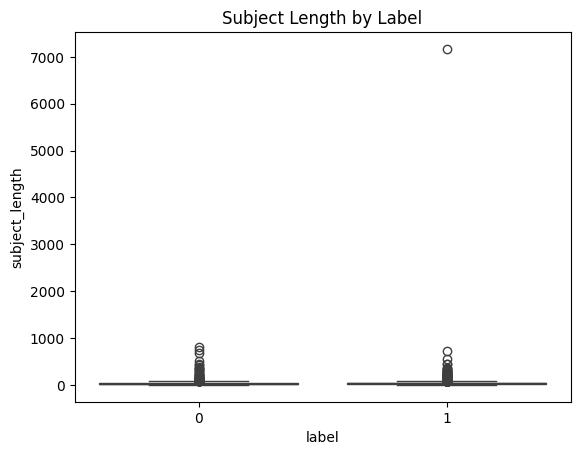

In [22]:
sns.boxplot(x='label', y='subject_length', data=df_enron)
plt.title("Subject Length by Label")
plt.show()


##BIVARIATE EDA : Body length by Label


In [23]:
df_enron.groupby('label')['body_length'].describe()


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,15791.0,1627.513457,5456.715359,1.0,324.0,783.0,1676.0,230120.0
1,13976.0,1329.990341,1982.377811,1.0,338.0,639.0,1418.0,31329.0


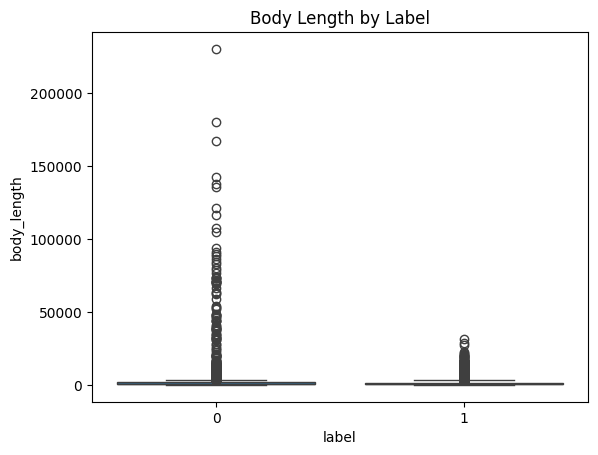

In [24]:
sns.boxplot(x='label', y='body_length', data=df_enron)
plt.title("Body Length by Label")
plt.show()


##Summary



* There are around 29,767 emails with 3 columns: subject, body, label.
* Subject and body are objects Label is numeric so int64.
* The only column that has missing values is subject (198 missing).Missing subjects are normal in email datasets, many emails simply have no subject line but once we explored it we discovered , a lot of the emails that has a subject missing is just low-quality phishing  emails.
* There are no duplicates in this dataset
* With the histogram of text length shows that legitimate emails tend to be longer and more detailed
* There seems to be around 53 % legit emails and around 46 % phishing emails
* Subject length is shown to have a mean of around 34, but the maximum subject length is 7170 which seems suspiciously long
*  From the box plot for body length by label we can clearly see that legit emails have a much high body-length compared to the phishing emails

##